# Praktikum Kecerdasan Artifisial Lanjut


---
## Bab 4. Pemrosesan Awal Data




Nama: Erza Hanif Pramudita Hanggara

NIM: 245150200111038

Kelas: TIF-A



### 1) Import Data

Unduh dataset yang akan digunakan pada praktikum kali ini. Anda dapat menggunakan aplikasi **wget** untuk mendowload dataset dan menyimpannya dalam Google Colab. Jalankan cell di bawah ini untuk mengunduh **dataset sebagai latihan awal**. Untuk **tugas** gunakan **dataset yang tertera di modul praktikum (ada perbedaan *dataset*)**.

In [8]:
! wget https://dataset-kal.s3.us-east-1.amazonaws.com/iris_missing.csv

--2026-03-18 08:28:59--  https://dataset-kal.s3.us-east-1.amazonaws.com/iris_missing.csv
Resolving dataset-kal.s3.us-east-1.amazonaws.com (dataset-kal.s3.us-east-1.amazonaws.com)... 52.216.40.74, 16.15.253.234, 54.231.166.82, ...
Connecting to dataset-kal.s3.us-east-1.amazonaws.com (dataset-kal.s3.us-east-1.amazonaws.com)|52.216.40.74|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4593 (4.5K) [text/csv]
Saving to: ‘iris_missing.csv.1’

iris_missing.csv.1  100%[===================>]   4.49K  --.-KB/s    in 0s      

2026-03-18 08:29:00 (157 MB/s) - ‘iris_missing.csv.1’ saved [4593/4593]



Setelah dataset berhasil diunduh, langkah berikutnya adalah membaca dataset dengan memanfaatkan fungsi [readcsv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) dari library pandas. Lakukan pembacaan berkas csv menggunakan fungsi **readcsv**. Jangan lupa untuk melakukan import library pandas terlebih dahulu

In [9]:
import pandas as pd
import numpy as np
data = pd.read_csv('iris_missing.csv')

Tampilkan beberapa baris dari dataset untuk mendapatkan informasi singkat mengenai isi data. Gunakan fungsi **head()** untuk menampilkan 5 data pertama.

In [10]:
data.head()

,sepal_length,sepal_width,petal_length,petal_width,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,0.0,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


Berdasarkan informasi dari fungsi **head()**, data iris yang
digunakan mempunyai 4 fitur sebagai berikut :


1.   sepal length
2.   sepal width
3.   petal length
4.   petal width

### 2) Cek Tipe Data dan Statistik Sederhana

Lakukan pengecekan untuk memastikan tipe data dari masing-masing fitur.

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


Apabila ada ketidaksesuaian tipe data, kita dapat mengubahnya (dengan melakukan type casting) secara manual.

In [12]:
data['sepal_length'] = data['sepal_length'].astype(np.float32)

Kemudian, coba panggil metode `info()` untuk mengecek kembali; dan `describe()` untuk mencoba cek statistik data. Lalu, jelaskan apa perbedaannya di bawahnya.

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float32
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float32(1), float64(3), object(1)
memory usage: 5.4+ KB


In [14]:
data.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.731334,2.988000,3.684667,1.147333
std,1.153351,0.604893,1.826675,0.773790
min,0.000000,0.000000,0.000000,0.000000
25%,5.100000,2.800000,1.500000,0.225000
50%,5.800000,3.000000,4.300000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


**Penjelasan**

Melakukan cek tipe data dengan info() kemudian merubah tipe data flloat dari 64 bit ke 32 bit untuk sepal_length dan dicek lagi dengan infoo(), dan melakukan cek statistik dengan describe().

### 3) Missing value dan imputasi data




Jika Anda perhatikan dengan seksama, data pada baris ke-3 (index 2) pada fitur sepal length memiliki nilai 0.0. Hal ini menandakan adanya missing value pada data. Jalankan cell di bawah ini untuk mendapatkan semua data yang mengandung missing value. Pencarian data yang mengandung missing value dilakukan dengan tahapan sebagai berikut:


1.   Membuat filter untuk mencari data dengan sepal_length = 0, sepal_width = 0, petal_length = 0, petal_width =0
2.   Mencari data yang memenuhi kondisi1 **atau** kondisi2 **atau** kondisi3 **atau** kondisi4 menggunakan property [loc](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.loc.html) pada dataframe



In [15]:
kondisi1 = data['sepal_length']==0.0
kondisi2 = data['sepal_width']==0.0
kondisi3 = data['petal_length']==0.0
kondisi4 = data['petal_width']==0.0
data.loc[kondisi1 | kondisi2 | kondisi3 | kondisi4]

,sepal_length,sepal_width,petal_length,petal_width,Species
2,0.0,3.2,1.3,0.2,Iris-setosa
11,0.0,3.4,1.6,0.2,Iris-setosa
32,5.2,0.0,1.5,0.1,Iris-setosa
47,4.6,3.2,0.0,0.2,Iris-setosa
51,6.4,0.0,4.5,1.5,Iris-versicolor
65,6.7,3.1,4.4,0.0,Iris-versicolor
67,5.8,2.7,0.0,1.0,Iris-versicolor
86,6.7,0.0,4.7,1.5,Iris-versicolor
107,0.0,2.9,6.3,1.8,Iris-virginica
112,6.8,3.0,0.0,2.1,Iris-virginica


Penanganan missing value pada Pandas akan lebih mudah apabila data yang hilang (bernilai 0.0) diganti dengan NaN (Not A Number). Gunakan properti **replace** pada dataframe untuk menggganti 0.0 menjadi NaN

In [16]:
data = data.replace(0.0, np.nan)

Terdapat beberapa cara untuk mengatasi permasalahan missing value pada data. Salah satu cara yang sederhana adalah dengan mengganti nilai NaN pada suatu fitur dengan rata-rata nilai fitur tersebut pada data lain yang bernilai bukan Nan. Perhatikan bahwa Anda harus mengganti nilai NaN dengan rata-rata data lain yang memiliki kategori (species) yang sama.

Fungsi-fungsi pada Pandas yang dapat Anda manfaatkan:


1.   **transform** untuk mengaplikasikan fungsi tertentu pada dataframe, pada permasalahan ini fungsi yang digunakan adalah fungsi **mean**
2.   **groupby** untuk mengelompokkan dataframe berdasarkan nilai kolom tertentu, pada permasalahan ini kolom yang digunakan adalah **species**
3. **fillna** untuk mengganti nilai NaN dengan nilai yang telah ditentukan




Buatlah fungsi bernama **imputasi** yang melakukan tahapan berikut:


1.   Menghitung rata-rata masing-masing kolom berdasarkan kelasnya
2.   Mengisi kolom yang berisi NaN dengan rata-rata kelas yang sesuai




In [17]:
def imputasi(df_input):
  list_columns = df_input.columns #mendapatkan daftar kolom pada DataFrame
  class_column = list_columns[-1] #kolom terakhir merupakan kolom kelas
  for column in list_columns[:-1]:
    # Penggantian nilai NaN dilakukan per kolom
    df_input[column] = df_input[column].fillna(
        df_input.groupby(class_column)[column].transform('mean'))
  return df_input

Buatlah sebuah dataframe baru bernama **data_imputasi** yang berisi dataset dengan nilai NaN yang sudah diganti dengan cara memanggil fungsi **imputasi**.

In [18]:
data_imputasi = imputasi(data)

Cek apakah masih terdapat nilai NaN pada dataframe.

In [19]:
data_imputasi.isnull().values.any()

np.False_

Coba juga dengan `data_imputasi.isna().any()`

In [20]:
data_imputasi.isna().any()

,0
sepal_length,False
sepal_width,False
petal_length,False
petal_width,False
Species,False


### 4) Pencarian Outlier

Untuk mencari outlier, dalam percobaan ini kita akan gunakan BoxPlot untuk memvisualisasikan outlier. Lakukan plotting terhadap semua fitur pada dataset Iris. Hasil yang diharapkan seperti contoh berikut:

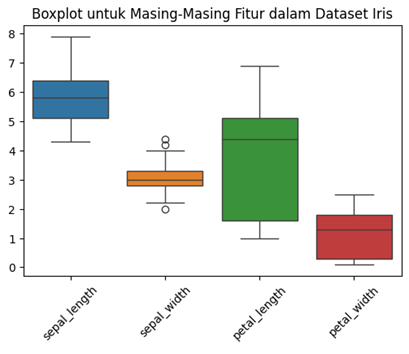

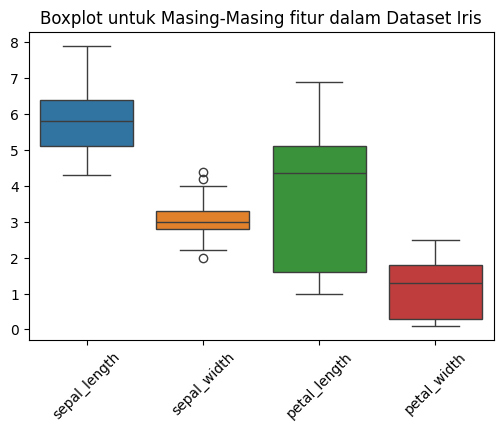

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(data=data_imputasi)
plt.xticks(rotation=45)
plt.title("Boxplot untuk Masing-Masing fitur dalam Dataset Iris")
plt.show()

Percobaan mencari *outlier* dengan kode Python

In [23]:
Q1 = data['sepal_width'].quantile(0.25)
Q3 = data['sepal_width'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

Setelah dapat melakukan pencarian outlier, penghapusan outlier dapat dilakukan dengan cara memfilter titik-titik data yang memenuhi syarat. Tulis kode di bawah.

In [25]:
data_without_outlier = data[~((data['sepal_width'] < lower_bound) |
                              (data['sepal_width'] > upper_bound))]

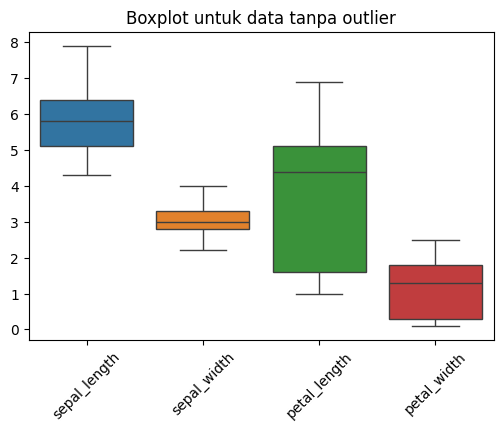

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(data=data_without_outlier)
plt.xticks(rotation=45)
plt.title("Boxplot untuk data tanpa outlier")
plt.show()

### 5) Normalisasi MinMax
Normalisasi bertujuan menyamakan rentang nilai pada setiap fitur. Beberapa metode pembelajaran mesin memiliki kinerja yang buruk apabila rentang nilai tiap variabel berbeda jauh.

Sebelum melakukan normalisasi, cek terlebih dahulu rentang (nilai max - nilai min) pada masing masing fitur

In [27]:
def cetak_rentang(df_input):
  #mengambil nama kolom, kecuali yang terakhir (kelas)
  list_fitur = df_input.columns[:-1]
  for fitur in list_fitur:
    max = df_input[fitur].max()
    min = df_input[fitur].min()
    print("Rentang fitur ",fitur," adalah ",max-min)

cetak_rentang(data_imputasi)

Rentang fitur  sepal_length  adalah  3.5999999046325684
Rentang fitur  sepal_width  adalah  2.4000000000000004
Rentang fitur  petal_length  adalah  5.9
Rentang fitur  petal_width  adalah  2.4


Terlihat bahwa masing-masing fitur memiliki rentang yang berbeda, meskipun tidak terlalu signifikan. Pada praktikum ini Anda akan mengimplementasikan normalisasi MinMax untuk menyamakan rentang setiap fitur menjadi satu (1). Persamaan dari fungsi normalisasi MinMax adalah sebagai berikut:

$x'=\frac{x-min(x)}{max(x)-min(x)}$

dimana $x'$ merupakan nilai ternormalisasi, $x$ adalah nilai asal, $min(x)$ merupakan nilai minimum pada suatu fitur, dan $max(x)$ merupakan nilai maksimum pada suatu fitur.

Implementasikan metode normalisasi MinMax pada fungsi bernama **minmax**.


In [28]:
def minmax(df_input):
  list_fitur = df_input.columns[:-1]
  for fitur in list_fitur:
    max = df_input[fitur].max()
    min = df_input[fitur].min()
    df_input[fitur] = (df_input[fitur]-min)/(max-min)

  return df_input

Buatlah sebuah dataframe baru bernama **data_normal** yang berisi hasil dari metode minmax dengan input **data_imputasi**

In [29]:
data_normal = minmax(data_imputasi)

Cek 5 baris pertama **data_normal**

In [30]:
data_normal.head()

,sepal_length,sepal_width,petal_length,petal_width,Species
0,0.222222,0.625000,0.067797,0.041667,Iris-setosa
1,0.166667,0.416667,0.067797,0.041667,Iris-setosa
2,0.199074,0.500000,0.050847,0.041667,Iris-setosa
3,0.083333,0.458333,0.084746,0.041667,Iris-setosa
4,0.194444,0.666667,0.067797,0.041667,Iris-setosa


Tampilkan rentang masing-masing fitur menggunakan fungsi **cetak_rentang** yang telah dibuat

In [31]:
cetak_rentang(data_normal)

Rentang fitur  sepal_length  adalah  1.0
Rentang fitur  sepal_width  adalah  1.0
Rentang fitur  petal_length  adalah  1.0
Rentang fitur  petal_width  adalah  1.0


### 6) Label Encoding

Dalam kasus data yang diberikan, tidak ada data atau fitur kategori atau ordinal, namun ada label kelas (target) yaitu: Iris-setosa, Iris-versicolor, Iris-virginica. Untuk mengubah ke data numerik, khusus pada label kelas ini kita melakukan dengan label encoding, sedangkan pada fitur (predictor) kita dapat
menggunakan label encoding atau one-hot encoding. Dalam contoh ini, akan digunakan lambda function. Buat fungsi yang akan dipanggil oleh lambda function.

In [32]:
def label_encoding(x):
  if 'setosa' in x:
    return 0
  if 'versicolor' in x:
    return 1
  if 'virginica' in x:
    return 2

Coba lakukan *encoding* pada target Species dari DataFrame hasil normalisasi sebelumnya.

In [36]:
data_normal['Species'] = data_normal['Species'].apply(label_encoding)

Tampilkan hasil DataFrame pada 10 data pertama dan terakhir menggunakan `head()` dan `tail()`

In [37]:
data_normal.head(10)

,sepal_length,sepal_width,petal_length,petal_width,Species
0,0.222222,0.625000,0.067797,0.041667,0
1,0.166667,0.416667,0.067797,0.041667,0
2,0.199074,0.500000,0.050847,0.041667,0
3,0.083333,0.458333,0.084746,0.041667,0
4,0.194444,0.666667,0.067797,0.041667,0
5,0.305556,0.791667,0.118644,0.125000,0
6,0.083333,0.583333,0.067797,0.083333,0
7,0.194444,0.583333,0.084746,0.041667,0
8,0.027778,0.375000,0.067797,0.041667,0
9,0.166667,0.458333,0.084746,0.000000,0


In [38]:
data_normal.tail(10)

,sepal_length,sepal_width,petal_length,petal_width,Species
140,0.666667,0.458333,0.779661,0.958333,2
141,0.722222,0.458333,0.694915,0.916667,2
142,0.416667,0.291667,0.694915,0.750000,2
143,0.694444,0.500000,0.830508,0.916667,2
144,0.666667,0.541667,0.796610,1.000000,2
145,0.666667,0.416667,0.711864,0.799645,2
146,0.555556,0.208333,0.677966,0.750000,2
147,0.611111,0.416667,0.711864,0.791667,2
148,0.527778,0.583333,0.745763,0.916667,2
149,0.444444,0.416667,0.694915,0.708333,2


## TUGAS

Dataset yang digunakan pada bagian TUGAS ini, yaitu: [https://dataset-kal.s3.us-east-1.amazonaws.com/iris_missing_nan.csv](https://dataset-kal.s3.us-east-1.amazonaws.com/iris_missing_nan.csv)

Lakukan perubahan yang sesuai terlebih dahulu untuk mengatasi *missing value* pada *dataset* tersebut.

In [39]:
# import semua library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
from google.colab import files
uploaded = files.upload()

Saving iris_missing_nan.csv to iris_missing_nan.csv


In [41]:
df = pd.read_csv('iris_missing_nan.csv')
df.head()

# bisa diisi df / data / irisMissingNan, terserah kalian.

,sepal_length,sepal_width,petal_length,petal_width,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3,1.4,0.2,Iris-setosa
2,?,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5,3.6,1.4,0.2,Iris-setosa


In [42]:
con1 = df['sepal_length'] == '?'
con2 = df['sepal_width'] == '?'
con3 = df['petal_length'] == '?'
con4 = df['petal_width'] == '?'

df.loc[con1 | con2 | con3 | con4]
(df == '?').sum()

,0
sepal_length,3
sepal_width,3
petal_length,3
petal_width,4
Species,0


In [44]:
df = df.replace('?', np.nan)

# Tampilkan Hasilnya
df.head()

,sepal_length,sepal_width,petal_length,petal_width,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3,1.4,0.2,Iris-setosa
2,NaN,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5,3.6,1.4,0.2,Iris-setosa


In [45]:
(df == '?').sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
Species,0


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   sepal_length  147 non-null    object
 1   sepal_width   147 non-null    object
 2   petal_length  147 non-null    object
 3   petal_width   146 non-null    object
 4   Species       150 non-null    object
dtypes: object(5)
memory usage: 6.0+ KB


In [49]:
# Mengubah tipe data kolom numerik menjadi float. Kecuali kolom kelas (Species)!
df['sepal_length'] = df['sepal_length'].astype(float)
df['sepal_width'] = df['sepal_width'].astype(float)
df['petal_length'] = df['petal_length'].astype(float)
df['petal_width'] = df['petal_width'].astype(float)

# Fungsi untuk imputasi nilai NaN berdasarkan rata-rata kelas
def imputasi_nan(df_input):
  list_fitur = df_input.columns[:-1]
  class_column = df_input.columns[-1]
  for fitur in list_fitur:
    df_input[fitur] = df_input[fitur].fillna(df_input.groupby
     (class_column)[fitur].transform('mean'))
  return df_input

df_imputasi = imputasi_nan(df)

In [61]:
df_imputasi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [50]:
# Cek apakah masih ada nilai NaN
df_imputasi.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
Species,0


In [51]:
# Cetak/tampilkan data di bawah
df_imputasi.head()

,sepal_length,sepal_width,petal_length,petal_width,Species
0,5.100000,3.5,1.4,0.2,Iris-setosa
1,4.900000,3.0,1.4,0.2,Iris-setosa
2,5.016667,3.2,1.3,0.2,Iris-setosa
3,4.600000,3.1,1.5,0.2,Iris-setosa
4,5.000000,3.6,1.4,0.2,Iris-setosa


### No. 1. Implementasikan metode normalisasi Z-score dengan cara membuat fungsi bernama **zscore**.

In [54]:
# Buat fungsi mean dan std terlebih dahulu
def mean(df_input):
  hasil = {}
  for fitur in df_input.columns[:-1]:
    hasil[fitur] = df_input[fitur].mean()
  return hasil

def std(df_input):
  hasil = {}
  for fitur in df_input.columns[:-1]:
    hasil[fitur] = df_input[fitur].std()
  return hasil

#Fungsi zscore
def zscore(df_input):
  mean_fitur = mean(df_input)
  std_fitur = std(df_input)

  for fitur in df_input.columns[:-1]:
    df_input[fitur] = (df_input[fitur] -
                        mean_fitur[fitur])/std_fitur[fitur]
  return df_input

**Penjelasan**

Membuat 3 fungsi, dimulai dari fungsi mean dan std yang disimpan dalam dict pasangan key fitur dan value nilainya dan kemudian direturn dict tersebut. Kemudian untuk fungsi zscore yang menerima input df dan memanggil fungsi mean dan std yang kemudian dilakukan loop tiap fitur untuk menghitung zscore masing masing fitur dan memanggil pula mean dan std masing masing fitur sesuai rumus zscore yang kemudian direturn hasil df akhir. Perhitungan yang terjadi itu sekaligus 1 kolom penuh dioperasikan bersama.

### No. 2. Normalisasikan dataframe **data_imputasi** menggunakan fungsi **zscore**. Simpan hasilnya pada dataframe bernama **data_zscore**.


In [56]:
# Hanya tinggal print/tampilkan data_zscore
data_zscore = zscore(df_imputasi)
data_zscore.head()

,sepal_length,sepal_width,petal_length,petal_width,Species
0,-0.907825,1.053430,-1.336763,-1.312509,Iris-setosa
1,-1.152507,-0.110540,-1.336763,-1.312509,Iris-setosa
2,-1.009776,0.355048,-1.393408,-1.312509,Iris-setosa
3,-1.519530,0.122254,-1.280117,-1.312509,Iris-setosa
4,-1.030166,1.286224,-1.336763,-1.312509,Iris-setosa


**Penjelasan**

Memanggil fungsi zscore sebelumnya dengan menyimpannya dalam var data_zscore dan mengoutputkan head untuk melihat hasil.

### No. 3. Jelaskan perbedaan hasil normalisasi **MinMax** dan **ZScore**. Petunjuk: cek nilai rentang, rata-rata dan standar deviasi dari **data_zscore**.


*Note: Tidak perlu cetak/tampilkan zscore kembali karena sudah dicetak di atas.*

In [58]:
cetak_rentang(data_zscore)

Rentang fitur  sepal_length  adalah  1.0
Rentang fitur  sepal_width  adalah  1.0
Rentang fitur  petal_length  adalah  1.0
Rentang fitur  petal_width  adalah  1.0


In [63]:
print(data_zscore[data_zscore.columns[:-1]].mean())
print(data_zscore[data_zscore.columns[:-1]].std())

sepal_length    0.428346
sepal_width     0.436452
petal_length    0.467774
petal_width     0.456894
dtype: float64
sepal_length    0.227052
sepal_width     0.178985
petal_length    0.299213
petal_width     0.316362
dtype: float64


**Penjelasan**

Dari hasil yang didapatkan, dapat diketahui bahwa min max memberi batasan nilai misal dari 0-1 sedangkan zscore bisa lebih bahkan minus, tapi rentang tetap sama yakni 1.

### Pencarian dan penghapusan OUTLIER

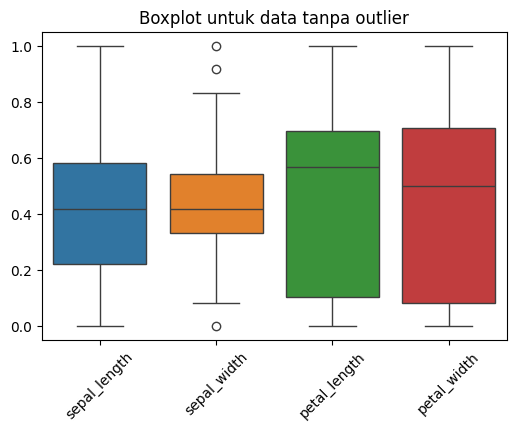

In [64]:
# Buat fungsi untuk mendeteksi dan menghapus outlier dengan IQR setelah data ternormalisasi
def detect_outlier(df_input):
  import seaborn as sns
  import matplotlib.pyplot as plt

  plt.figure(figsize=(6,4))
  sns.boxplot(data=df_input)
  plt.xticks(rotation=45)
  plt.title("Boxplot untuk data tanpa outlier")
  plt.show()

detect_outlier(data_zscore)

In [69]:
def remove_outlier(df_input):
  Q1 = data['sepal_width'].quantile(0.25)
  Q3 = data['sepal_width'].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  df_input = df_input[~((df_input['sepal_width'] < lower_bound) |
                        (df_input['sepal_width'] > upper_bound))]
  return df_input

data_zscore_without_outlier = remove_outlier(data_zscore)

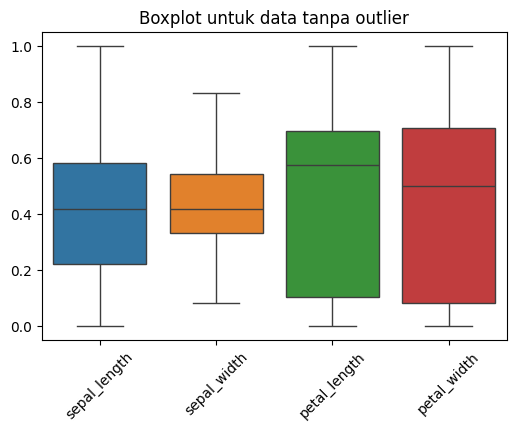

In [70]:
# Tampilkan hasilnya (menggunakan plt)
detect_outlier(data_zscore_without_outlier)

**Penjelasan**

Menghilangkan outlier dengan IQR yang didefinisikan dalam fungsi dan kemudian di plot seperti bagian sebelumnya

### **Kesimpulan**

Preprocessing data dengan menghilangkan missing value, lalu menormalisasi data dapat dilakukan dengan cukup mudah di python dengan bantuan librarynya.